#Install and download data

---



In [21]:
!pip install -q gensim

import nltk
nltk.download('brown')
nltk.download('treebank')
nltk.download('conll2000')
nltk.download('universal_tagset')

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Package treebank is already up-to-date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


True

#Cell 2: Imports

In [22]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import brown, treebank, conll2000
from gensim.models import KeyedVectors
import gensim.downloader as api

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, Dense, Input, TimeDistributed,
                                     LSTM, GRU, Bidirectional, SimpleRNN)

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

In [23]:
treebank_corpus = treebank.tagged_sents(tagset='universal')
brown_corpus = brown.tagged_sents(tagset='universal')
conll_corpus = conll2000.tagged_sents(tagset='universal')

tagged_sentences = treebank_corpus + brown_corpus + conll_corpus
print(len(tagged_sentences))
tagged_sentences[2]

72202


[('Rudolph', 'NOUN'),
 ('Agnew', 'NOUN'),
 (',', '.'),
 ('55', 'NUM'),
 ('years', 'NOUN'),
 ('old', 'ADJ'),
 ('and', 'CONJ'),
 ('former', 'ADJ'),
 ('chairman', 'NOUN'),
 ('of', 'ADP'),
 ('Consolidated', 'NOUN'),
 ('Gold', 'NOUN'),
 ('Fields', 'NOUN'),
 ('PLC', 'NOUN'),
 (',', '.'),
 ('was', 'VERB'),
 ('named', 'VERB'),
 ('*-1', 'X'),
 ('a', 'DET'),
 ('nonexecutive', 'ADJ'),
 ('director', 'NOUN'),
 ('of', 'ADP'),
 ('this', 'DET'),
 ('British', 'ADJ'),
 ('industrial', 'ADJ'),
 ('conglomerate', 'NOUN'),
 ('.', '.')]

## Divide data in words (X) and tags (Y)

Since this is a **many-to-many** problem, each data point is a different sentence of the corpora.

Each data point has multiple words in the **input sequence**. This is what we call **X**.

Each word has its corresponding tag in the **output sequence**. This is what we call **Y**.

Sample dataset:

| X | Y |
|---|---|
| Mr. Vinken is chairman of Elsevier | NOUN NOUN VERB NOUN ADP NOUN |
| We have no useful information | PRON VERB DET ADJ NOUN |

In [24]:
X = []  # store input sequence
Y = []  # store output sequence

for sentence in tagged_sentences:
    X_sentence = []
    Y_sentence = []
    for entity in sentence:
        X_sentence.append(entity[0])  # entity[0] contains the word
        Y_sentence.append(entity[1])  # entity[1] contains corresponding tag

    X.append(X_sentence)
    Y.append(Y_sentence)

print(X[0])
print(Y[0])

['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.']
['NOUN', 'NOUN', '.', 'NUM', 'NOUN', 'ADJ', '.', 'VERB', 'VERB', 'DET', 'NOUN', 'ADP', 'DET', 'ADJ', 'NOUN', 'NOUN', 'NUM', '.']


In [25]:
num_words = len(set([word.lower() for sentence in X for word in sentence]))
num_tags = len(set([word.lower() for sentence in Y for word in sentence]))

In [26]:
print("Total number of tagged sentences: {}".format(len(X)))
print("Vocabulary size: {}".format(num_words))
print("Total number of tags: {}".format(num_tags))

Total number of tagged sentences: 72202
Vocabulary size: 59448
Total number of tags: 12


In [27]:
# let's look at first data point
# this is one data point that will be fed to the RNN
print('sample X: ', X[0], '\n')
print('sample Y: ', Y[0], '\n')

sample X:  ['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.'] 

sample Y:  ['NOUN', 'NOUN', '.', 'NUM', 'NOUN', 'ADJ', '.', 'VERB', 'VERB', 'DET', 'NOUN', 'ADP', 'DET', 'ADJ', 'NOUN', 'NOUN', 'NUM', '.'] 



In [28]:
# In this many-to-many problem, the length of each input and output sequence must be the same.
# Since each word is tagged, it's important to make sure that the length of input sequence equals the output sequence
print("Length of first input sequence  : {}".format(len(X[0])))
print("Length of first output sequence : {}".format(len(Y[0])))

Length of first input sequence  : 18
Length of first output sequence : 18


## Vectorise X and Y

**Encode X and Y to integer values**

We'll use the `Tokenizer()` function from the Keras library to encode a text sequence to an integer sequence.

In [29]:
X[1]

['Mr.',
 'Vinken',
 'is',
 'chairman',
 'of',
 'Elsevier',
 'N.V.',
 ',',
 'the',
 'Dutch',
 'publishing',
 'group',
 '.']

In [30]:
try:
    from tensorflow.keras.preprocessing.text import Tokenizer
except ImportError:
    from keras.legacy.preprocessing.text import Tokenizer  # Keras 3 fallback

In [ ]:
# encode X

word_tokenizer = Tokenizer()                      # instantiate tokeniser
word_tokenizer.fit_on_texts(X)                    # fit tokeniser on data
X_encoded = word_tokenizer.texts_to_sequences(X)  # use the tokeniser to encode input sequence

In [31]:
# encode Y

tag_tokenizer = Tokenizer()
tag_tokenizer.fit_on_texts(Y)
Y_encoded = tag_tokenizer.texts_to_sequences(Y)

In [32]:
print(X_encoded[0])
print(Y_encoded[0])
print(len(word_tokenizer.word_index), len(tag_tokenizer.word_index))

[6423, 24231, 2, 7652, 102, 170, 2, 47, 1898, 1, 269, 17, 7, 13230, 619, 1711, 2761, 3]
[1, 1, 3, 11, 1, 6, 3, 2, 2, 5, 1, 4, 5, 6, 1, 1, 11, 3]
59448 12


In [33]:
# look at first encoded data point

print("** Raw data point **", "\n", "-"*100, "\n")
print('X: ', X[0], '\n')
print('Y: ', Y[0], '\n')
print()
print("** Encoded data point **", "\n", "-"*100, "\n")
print('X: ', X_encoded[0], '\n')
print('Y: ', Y_encoded[0], '\n')

** Raw data point ** 
 ---------------------------------------------------------------------------------------------------- 

X:  ['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.'] 

Y:  ['NOUN', 'NOUN', '.', 'NUM', 'NOUN', 'ADJ', '.', 'VERB', 'VERB', 'DET', 'NOUN', 'ADP', 'DET', 'ADJ', 'NOUN', 'NOUN', 'NUM', '.'] 


** Encoded data point ** 
 ---------------------------------------------------------------------------------------------------- 

X:  [6423, 24231, 2, 7652, 102, 170, 2, 47, 1898, 1, 269, 17, 7, 13230, 619, 1711, 2761, 3] 

Y:  [1, 1, 3, 11, 1, 6, 3, 2, 2, 5, 1, 4, 5, 6, 1, 1, 11, 3] 



In [34]:
# make sure that each sequence of input and output is same length

different_length = [1 if len(input) != len(output) else 0 for input, output in zip(X_encoded, Y_encoded)]
print("{} sentences have disparate input-output lengths.".format(sum(different_length)))

0 sentences have disparate input-output lengths.


## Pad sequences

The next step after encoding the data is to **define the sequence lengths**. As of now, the sentences in the data are of various lengths. We need to either pad short sentences or truncate long sentences to a fixed length. This fixed length, however, is a **hyperparameter**.

In [35]:
# check length of longest sentence
lengths = [len(seq) for seq in X_encoded]
print("Length of longest sentence: {}".format(max(lengths)))

Length of longest sentence: 271


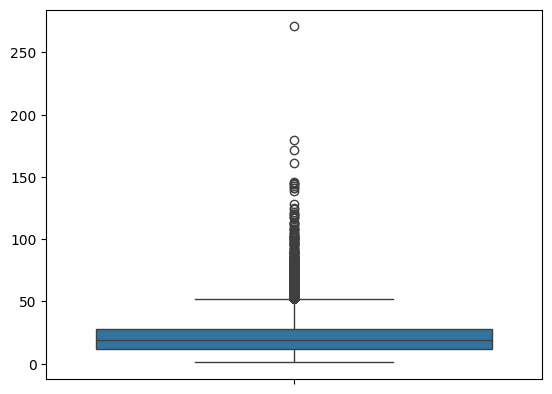

In [ ]:
sns.boxplot(lengths)
plt.show()

In [36]:
# Pad each sequence to MAX_SEQ_LENGTH using KERAS' pad_sequences() function.
# Sentences longer than MAX_SEQ_LENGTH are truncated.
# Sentences shorter than MAX_SEQ_LENGTH are padded with zeroes.

# Truncation and padding can either be 'pre' or 'post'.
# For padding we are using 'pre' padding type, that is, add zeroes on the left side.
# For truncation, we are using 'post', that is, truncate a sentence from right side.

MAX_SEQ_LENGTH = 100  # sequences greater than 100 in length will be truncated

X_padded = pad_sequences(X_encoded, maxlen=MAX_SEQ_LENGTH, padding="pre", truncating="post")
Y_padded = pad_sequences(Y_encoded, maxlen=MAX_SEQ_LENGTH, padding="pre", truncating="post")

In [ ]:
# print the first sequence
print(X_padded[0], "\n"*3)
print(Y_padded[0])

[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0  6423 24231
     2  7652   102   170     2    47  1898     1   269    17     7 13230
   619  1711  2761     3] 



[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  1  1  3 11  1  6  3  2  2  5  1  4  5  6
  1  1 11  3]


In [37]:
# assign padded sequences to X and Y
X, Y = X_padded, Y_padded

## Word embeddings

Currently, each word and each tag is encoded as an integer.

We'll use a more sophisticated technique to represent the input words (X) using what's known as **word embeddings**.

However, to represent each tag in Y, we'll simply use **one-hot encoding** scheme since there are only 13 tags in the dataset and the LSTM will have no problems in learning its own representation of these tags.

To use word embeddings, you can go for either of the following models:

1. word2vec model: https://code.google.com/archive/p/word2vec/
2. GloVe model: https://nlp.stanford.edu/projects/glove/

We're using the word2vec model for no particular reason. Both of these are very efficient in representing words. You can try both and see which one works better.

Dimensions of a word embedding is: (VOCABULARY_SIZE, EMBEDDING_DIMENSION)

### Use word embeddings for input sequences (X)

In [39]:
# The notebook loads GoogleNews-vectors-negative300.bin (~1.5GB) from a Google Drive link.
# In Colab, the simplest way is gensim's downloader, which fetches the same model.
import gensim.downloader as api

word2vec = api.load("word2vec-google-news-300")   # KeyedVectors, 300-dim
EMBEDDING_SIZE = 300

In [40]:
print(word2vec.vector_size)        # 300
print(word2vec['king'].shape)      # (300,)

300
(300,)


In [41]:
# word2vec effectiveness
word2vec.most_similar(positive=["King", "Woman"], negative=["Man"])

[('Queen', 0.4929387867450714),
 ('Tupou_V.', 0.45174285769462585),
 ('Oprah_BFF_Gayle', 0.4422132968902588),
 ('Jackson', 0.440250426530838),
 ('NECN_Alison', 0.4331282675266266),
 ('Whitfield', 0.42834725975990295),
 ('Ida_Vandross', 0.42084527015686035),
 ('prosecutor_Dan_Satterberg', 0.420758992433548),
 ('martin_Luther_King', 0.42059651017189026),
 ('Coretta_King', 0.4202733635902405)]

In [42]:
word2vec.most_similar("robot", topn=5)
word2vec.most_similar(positive=["Paris", "Italy"], negative=["France"], topn=3)

[('Milan', 0.7222140431404114),
 ('Rome', 0.7028310298919678),
 ('Palermo_Sicily', 0.5967570543289185)]

In [43]:
# assign word vectors from word2vec model

EMBEDDING_SIZE = 300  # each word in word2vec model is represented using a 300 dimensional vector
VOCABULARY_SIZE = len(word_tokenizer.word_index) + 1

# create an empty embedding matrix
embedding_weights = np.zeros((VOCABULARY_SIZE, EMBEDDING_SIZE))

# create a word to index dictionary mapping
word2id = word_tokenizer.word_index

# copy vectors from word2vec model to the words present in corpus
for word, index in word2id.items():
    try:
        embedding_weights[index, :] = word2vec[word]
    except KeyError:
        pass

In [44]:
# check embedding dimension
print("Embeddings shape: {}".format(embedding_weights.shape))

Embeddings shape: (59449, 300)


In [45]:
# let's look at an embedding of a word
embedding_weights[word_tokenizer.word_index['joy']]

array([ 0.4453125 , -0.20019531,  0.20019531, -0.03149414,  0.078125  ,
       -0.390625  ,  0.13671875, -0.13867188,  0.05395508,  0.10546875,
       -0.05029297, -0.23730469,  0.19921875,  0.12597656, -0.12695312,
        0.34179688,  0.06347656,  0.26757812, -0.07324219, -0.29101562,
        0.10498047,  0.11914062,  0.23730469,  0.00640869,  0.12451172,
       -0.00939941, -0.02770996,  0.03076172,  0.07421875, -0.22851562,
       -0.08056641, -0.05273438,  0.16894531,  0.19824219, -0.15625   ,
       -0.08740234,  0.10742188, -0.07177734,  0.05200195,  0.25976562,
        0.171875  , -0.13574219,  0.06738281,  0.00531006,  0.15527344,
       -0.03515625,  0.08789062,  0.3359375 , -0.12890625,  0.17578125,
       -0.08642578,  0.32421875, -0.09033203,  0.35351562,  0.24316406,
       -0.07470703, -0.06640625, -0.17578125,  0.06689453, -0.03833008,
        0.0100708 , -0.21484375, -0.03686523,  0.04394531,  0.02209473,
        0.00219727, -0.22460938,  0.03015137, -0.21582031,  0.16

In [46]:
  covered = int((np.abs(embedding_weights).sum(axis=1) > 0).sum())
  print(f"{covered} of {VOCABULARY_SIZE - 1} words found in word2vec")

36798 of 59448 words found in word2vec


In [47]:
# use Keras' to_categorical function to one-hot encode Y
Y = to_categorical(Y)

In [48]:
# print Y of the first output sequence
print(Y.shape)

(72202, 100, 13)


In [49]:
  print(Y[0][-1])              # one-hot vector of the last position (a real tag, since padding is on the left)
  print(Y[0][0])               # position 0 is padding, so class 0 should be 1

[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [50]:
# split entire data into training and testing sets
TEST_SIZE = 0.15
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=TEST_SIZE, random_state=4)

In [51]:
# split training data into training and validation sets
VALID_SIZE = 0.15
X_train, X_validation, Y_train, Y_validation = train_test_split(X_train, Y_train, test_size=VALID_SIZE, random_state=7)

In [52]:
# print number of samples in each set
print("TRAINING DATA")
print('Shape of input sequences: {}'.format(X_train.shape))
print('Shape of output sequences: {}'.format(Y_train.shape))
print("-"*50)
print("VALIDATION DATA")
print('Shape of input sequences: {}'.format(X_validation.shape))
print('Shape of output sequences: {}'.format(Y_validation.shape))
print("-"*50)
print("TESTING DATA")
print('Shape of input sequences: {}'.format(X_test.shape))
print('Shape of output sequences: {}'.format(Y_test.shape))

TRAINING DATA
Shape of input sequences: (52165, 100)
Shape of output sequences: (52165, 100, 13)
--------------------------------------------------
VALIDATION DATA
Shape of input sequences: (9206, 100)
Shape of output sequences: (9206, 100, 13)
--------------------------------------------------
TESTING DATA
Shape of input sequences: (10831, 100)
Shape of output sequences: (10831, 100, 13)


## Build the RNN

Before using an RNN, we must make sure the dimensions of the data are what an RNN expects. In general, an RNN expects the following shapes:

Shape of X: (#samples, #timesteps, #features)

Shape of Y: (#samples, #timesteps, #features)

In [53]:
print("X_train:", X_train.shape)   # (52165, 100)
print("Y_train:", Y_train.shape)   # (52165, 100, 13)

X_train: (52165, 100)
Y_train: (52165, 100, 13)


## 2. Vanilla RNN

### Uninitialised fixed embeddings

First let's try running a vanilla RNN. For this RNN we won't use the pre-trained word embeddings. We'll use randomly initialised embeddings. Moreover, we won't update the embedding weights.

In [54]:
# total number of tags
NUM_CLASSES = Y.shape[2]

In [55]:
from tensorflow.keras.layers import Input

# create architecture

rnn_model = Sequential()
rnn_model.add(Input(shape=(MAX_SEQ_LENGTH,)))

# create embedding layer - usually the first layer in text problems
rnn_model.add(Embedding(input_dim=VOCABULARY_SIZE,     # vocabulary size - number of unique words in data
                        output_dim=EMBEDDING_SIZE,     # length of vector with which each word is represented
                        trainable=False                # False - don't update the embeddings
))

# add an RNN layer which contains 64 RNN cells
rnn_model.add(SimpleRNN(64,
                        return_sequences=True  # True - return whole sequence; False - return single output of the end of the sequence
))

# add time distributed (output at each sequence) layer
rnn_model.add(TimeDistributed(Dense(NUM_CLASSES, activation='softmax')))

### Compile model

In [56]:
rnn_model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['acc'])

In [57]:
# check summary of the model
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 300)       │    17,834,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100, 64)        │        23,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 13)        │           845 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,858,905 (68.13 MB)

 Trainable params: 24,205 (94.55 KB)

 Non-trainable params: 17,834,700 (68.03 MB)

### Fit model

In [58]:
rnn_training = rnn_model.fit(X_train, Y_train, batch_size=128, epochs=10,
                             validation_data=(X_validation, Y_validation))

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 114s 261ms/step - acc: 0.8528 - loss: 0.5166 - val_acc: 0.8945 - val_loss: 0.3457
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 106s 260ms/step - acc: 0.9111 - loss: 0.2888 - val_acc: 0.9246 - val_loss: 0.2447
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 97s 239ms/step - acc: 0.9317 - loss: 0.2197 - val_acc: 0.9371 - val_loss: 0.1980
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 91s 224ms/step - acc: 0.9409 - loss: 0.1848 - val_acc: 0.9445 - val_loss: 0.1724
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 90s 220ms/step - acc: 0.9468 - loss: 0.1646 - val_acc: 0.9488 - val_loss: 0.1566
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 90s 221ms/step - acc: 0.9507 - loss: 0.1513 - val_acc: 0.9521 - val_loss: 0.1458
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 82s 200ms/step - acc: 0.9532 - loss: 0.1423 - val_acc: 0.9540 - val_loss: 0.1393
Epoch 8/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 83s 202ms/step - acc: 0.9550 - loss: 0.1359 - val_acc: 0.9556 - val_loss: 0.1330
Epoch 9/10
408/408 ━━━━━━━━━━━

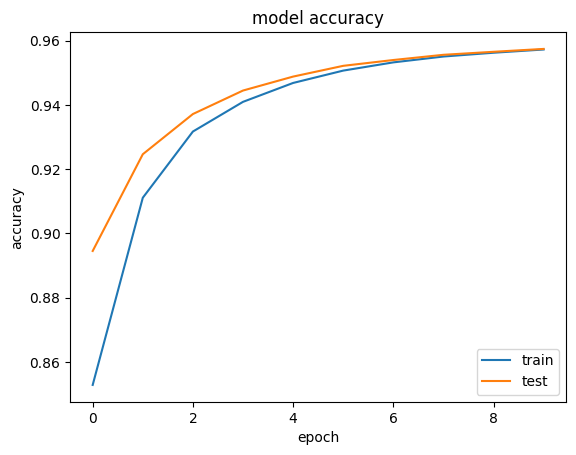

In [59]:
# visualise training history
plt.plot(rnn_training.history['acc'])
plt.plot(rnn_training.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc="lower right")
plt.show()

### Uninitialised trainable embeddings

In [60]:
rnn_fixed_model = rnn_model
rnn_fixed_training = rnn_training

In [61]:
# create architecture

rnn_model = Sequential()
rnn_model.add(Input(shape=(MAX_SEQ_LENGTH,)))

# create embedding layer - usually the first layer in text problems
rnn_model.add(Embedding(input_dim=VOCABULARY_SIZE,     # vocabulary size - number of unique words in data
                        output_dim=EMBEDDING_SIZE,     # length of vector with which each word is represented
                        trainable=True                 # True - update the embeddings while training
))

# add an RNN layer which contains 64 RNN cells
rnn_model.add(SimpleRNN(64,
                        return_sequences=True  # True - return whole sequence; False - return single output of the end of the sequence
))

# add time distributed (output at each sequence) layer
rnn_model.add(TimeDistributed(Dense(NUM_CLASSES, activation='softmax')))

### Compile model

In [62]:
rnn_model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['acc'])

In [63]:
# check summary of the model
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 300)       │    17,834,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 100, 64)        │        23,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 100, 13)        │           845 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,858,905 (68.13 MB)

 Trainable params: 17,858,905 (68.13 MB)

 Non-trainable params: 0 (0.00 B)

### Fit model

In [64]:
rnn_training = rnn_model.fit(X_train, Y_train, batch_size=128, epochs=10,
                             validation_data=(X_validation, Y_validation))

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 215s 504ms/step - acc: 0.9605 - loss: 0.1488 - val_acc: 0.9870 - val_loss: 0.0436
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 251s 478ms/step - acc: 0.9899 - loss: 0.0312 - val_acc: 0.9898 - val_loss: 0.0298
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 202s 478ms/step - acc: 0.9928 - loss: 0.0211 - val_acc: 0.9905 - val_loss: 0.0271
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 204s 484ms/step - acc: 0.9940 - loss: 0.0172 - val_acc: 0.9907 - val_loss: 0.0265
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 198s 486ms/step - acc: 0.9949 - loss: 0.0146 - val_acc: 0.9907 - val_loss: 0.0269
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 199s 487ms/step - acc: 0.9957 - loss: 0.0125 - val_acc: 0.9905 - val_loss: 0.0278
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 198s 485ms/step - acc: 0.9964 - loss: 0.0106 - val_acc: 0.9903 - val_loss: 0.0295
Epoch 8/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 201s 493ms/step - acc: 0.9970 - loss: 0.0089 - val_acc: 0.9901 - val_loss: 0.0314
Epoch 9/10
408/408 ━━━━━

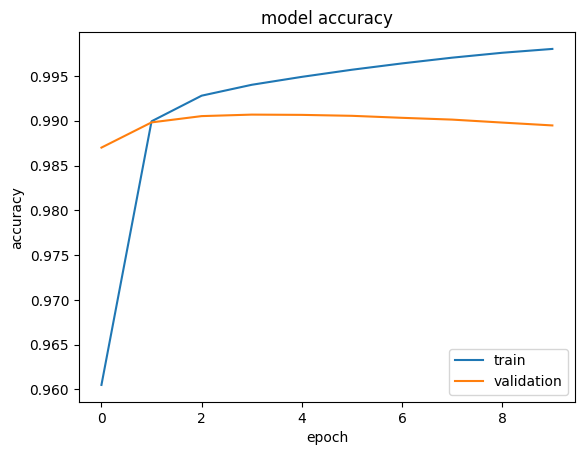

In [65]:
# visualise training history
plt.plot(rnn_training.history['acc'])
plt.plot(rnn_training.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc="lower right")
plt.show()

### Using pre-trained embedding weights

In [66]:
rnn_trainable_model = rnn_model
rnn_trainable_training = rnn_training

In [67]:
# create architecture

rnn_model = Sequential()
rnn_model.add(Input(shape=(MAX_SEQ_LENGTH,)))

# create embedding layer - usually the first layer in text problems
rnn_model.add(Embedding(input_dim=VOCABULARY_SIZE,       # vocabulary size - number of unique words in data
                        output_dim=EMBEDDING_SIZE,       # length of vector with which each word is represented
                        weights=[embedding_weights],     # word embedding matrix
                        trainable=True                   # True - update the embeddings while training
))

# add an RNN layer which contains 64 RNN cells
rnn_model.add(SimpleRNN(64,
                        return_sequences=True  # True - return whole sequence; False - return single output of the end of the sequence
))

# add time distributed (output at each sequence) layer
rnn_model.add(TimeDistributed(Dense(NUM_CLASSES, activation='softmax')))

In [68]:
rnn_model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['acc'])

In [69]:
rnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 300)       │    17,834,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 100, 64)        │        23,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 100, 13)        │           845 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,858,905 (68.13 MB)

 Trainable params: 17,858,905 (68.13 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
rnn_training = rnn_model.fit(X_train, Y_train, batch_size=128, epochs=10,
                             validation_data=(X_validation, Y_validation))

Epoch 1/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 213s 495ms/step - acc: 0.9699 - loss: 0.1226 - val_acc: 0.9890 - val_loss: 0.0344
Epoch 2/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 253s 479ms/step - acc: 0.9910 - loss: 0.0265 - val_acc: 0.9906 - val_loss: 0.0268
Epoch 3/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 200s 489ms/step - acc: 0.9929 - loss: 0.0200 - val_acc: 0.9911 - val_loss: 0.0249
Epoch 4/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 198s 478ms/step - acc: 0.9939 - loss: 0.0170 - val_acc: 0.9913 - val_loss: 0.0244
Epoch 5/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 195s 478ms/step - acc: 0.9946 - loss: 0.0150 - val_acc: 0.9914 - val_loss: 0.0245
Epoch 6/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 204s 484ms/step - acc: 0.9953 - loss: 0.0132 - val_acc: 0.9913 - val_loss: 0.0252
Epoch 7/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 196s 480ms/step - acc: 0.9960 - loss: 0.0115 - val_acc: 0.9911 - val_loss: 0.0263
Epoch 8/10
408/408 ━━━━━━━━━━━━━━━━━━━━ 197s 484ms/step - acc: 0.9966 - loss: 0.0100 - val_acc: 0.9909 - val_loss: 0.0276
Epoch 9/10
408/408 ━━━━━

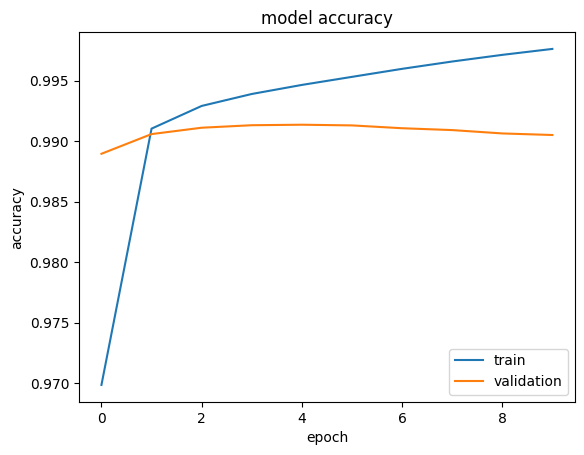

In [71]:
# visualise training history
plt.plot(rnn_training.history['acc'])
plt.plot(rnn_training.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc="lower right")
plt.show()

## 2. LSTM

We'll use pre-trained word embeddings in following models and allow them to be updated as well.

### Create model architecture

In [72]:
# create architecture

lstm_model = Sequential()
lstm_model.add(Input(shape=(MAX_SEQ_LENGTH,)))
lstm_model.add(Embedding(input_dim=VOCABULARY_SIZE,      # vocabulary size - number of unique words in data
                         output_dim=EMBEDDING_SIZE,      # length of vector with which each word is represented
                         weights=[embedding_weights],    # word embedding matrix
                         trainable=True                  # True - update embeddings_weight matrix
))
lstm_model.add(LSTM(64, return_sequences=True))
lstm_model.add(TimeDistributed(Dense(NUM_CLASSES, activation='softmax')))

In [73]:
lstm_model.compile(loss='categorical_crossentropy',
                   optimizer='adam',
                   metrics=['acc'])

In [74]:
# check summary of the model
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 300)       │    17,834,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 64)        │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 100, 13)        │           845 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,928,985 (68.39 MB)

 Trainable params: 17,928,985 (68.39 MB)

 Non-trainable params: 0 (0.00 B)

## 2. GRU

### Create model architecture

In [75]:
# create architecture

gru_model = Sequential()
gru_model.add(Input(shape=(MAX_SEQ_LENGTH,)))
gru_model.add(Embedding(input_dim=VOCABULARY_SIZE,      # vocabulary size - number of unique words in data
                        output_dim=EMBEDDING_SIZE,      # length of vector with which each word is represented
                        weights=[embedding_weights],    # word embedding matrix
                        trainable=True                  # True - update embeddings_weight matrix
))
gru_model.add(GRU(64, return_sequences=True))
gru_model.add(TimeDistributed(Dense(NUM_CLASSES, activation='softmax')))

## 3. Bidirectional LSTM

### Create model architecture

In [76]:
# create architecture

bidirect_model = Sequential()
bidirect_model.add(Input(shape=(MAX_SEQ_LENGTH,)))
bidirect_model.add(Embedding(input_dim=VOCABULARY_SIZE,      # vocabulary size - number of unique words in data
                             output_dim=EMBEDDING_SIZE,      # length of vector with which each word is represented
                             weights=[embedding_weights],    # word embedding matrix
                             trainable=True                  # True - update embeddings_weight matrix
))
bidirect_model.add(Bidirectional(LSTM(64, return_sequences=True)))
bidirect_model.add(TimeDistributed(Dense(NUM_CLASSES, activation='softmax')))